In [1]:
import pandas as pd
import numpy as np

In [2]:
!pip install legacy-cgi
!pip install opendatasets
import opendatasets as od

od.download("https://www.kaggle.com/competitions/titanic")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dostonbekashirov
Your Kaggle Key: ··········


100%|██████████| 34.1k/34.1k [00:00<00:00, 35.2MB/s]


Extracting archive ./titanic/titanic.zip to ./titanic


In [3]:
df = pd.read_csv("/content/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#1-topshiriq. sigmoid(z) funksiyasini yozing. z = -2, 0, 0.5, 2 uchun hisoblang

In [7]:
import numpy as np

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

# Hisoblang z = -2, 0, 0.5, 2
z_values = [-2, 0, 0.5, 2]
results = {z: sigmoid(z) for z in z_values}

for z, res in results.items():
  print(f"sigmoid({z}) = {res:.4f}")

sigmoid(-2) = 0.1192
sigmoid(0) = 0.5000
sigmoid(0.5) = 0.6225
sigmoid(2) = 0.8808


In [8]:
import numpy as np

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

# Hisoblang z = -2
print(f"sigmoid(-2) = {sigmoid(-2):.4f}")

# Hisoblang z = 0
print(f"sigmoid(0) = {sigmoid(0):.4f}")

# Hisoblang z = 0.5
print(f"sigmoid(0.5) = {sigmoid(0.5):.4f}")

# Hisoblang z = 2
print(f"sigmoid(2) = {sigmoid(2):.4f}")

sigmoid(-2) = 0.1192
sigmoid(0) = 0.5000
sigmoid(0.5) = 0.6225
sigmoid(2) = 0.8808


In [9]:
# Berilgan w va b qiymatlari
w = 2.5
b = -1.4

# x = 0 uchun ehtimollikni hisoblang
x_0 = 0
probability_0 = sigmoid(w * x_0 + b)
print(f"x = {x_0} bo'lganda ehtimollik: {probability_0:.4f}")

# x = 1 uchun ehtimollikni hisoblang
x_1 = 1
probability_1 = sigmoid(w * x_1 + b)
print(f"x = {x_1} bo'lganda ehtimollik: {probability_1:.4f}")

x = 0 bo'lganda ehtimollik: 0.1978
x = 1 bo'lganda ehtimollik: 0.7503


#3-topshiriq. z ni -6 dan +6 gacha o'zgartirib sigmoid grafigini chizing

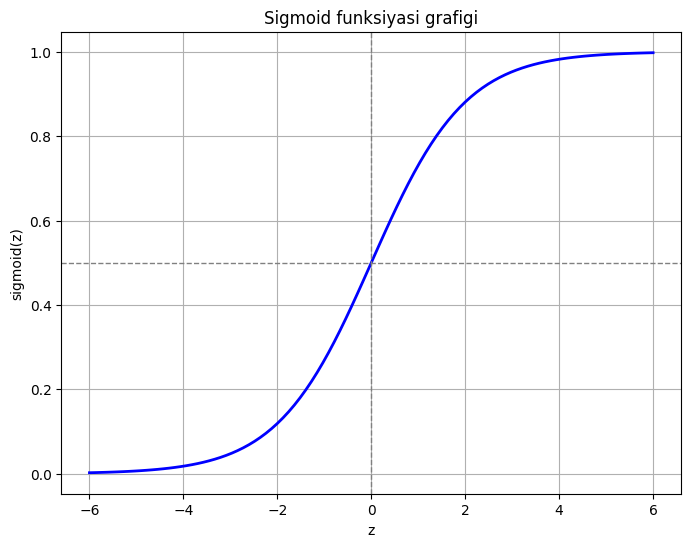

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

# z ni -6 dan 6 gacha oralig'ini hosil qilish
z = np.linspace(-6, 6, 100)
# Har bir z qiymati uchun sigmoid funksiyasini hisoblash
y = sigmoid(z)

plt.figure(figsize=(8,6))
plt.plot(z, y, color='blue', linewidth=2)
plt.title('Sigmoid funksiyasi grafigi')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.grid(True)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)  # y=0.5 chizig'i
plt.axvline(0, color='gray', linestyle='--', linewidth=1)    # z=0 chizig'i
plt.show()

#4-topshiriq. Fare bilan LinearRegression quring. Nechta bashorat 0, -1 dan chiqdi.

In [11]:
from sklearn.linear_model import LinearRegression
X = df[['Fare']] # Изменено с 'fare' на 'Fare'
y = df['Survived'] # Изменено с 'survived' на 'Survived' для соответствия регистру

lr = LinearRegression()
lr.fit(X, y)

pred = lr.predict(X)
print(pred)

[0.32096585 0.4822988  0.32266652 0.43648568 0.32298146 0.32401018
 0.43336777 0.35579816 0.33074988 0.37846323 0.34477528 0.36959251
 0.32298146 0.38149723 0.32248814 0.34301161 0.37608027 0.33545307
 0.34805065 0.32090286 0.36820678 0.33545307 0.32292905 0.39214219
 0.35579816 0.38178067 0.32090286 0.96533219 0.32255113 0.32259295
 0.37254236 0.67186092 0.3222256  0.32915427 0.50973004 0.43371421
 0.32091344 0.32298146 0.34805065 0.331023   0.32657177 0.3556092
 0.32259295 0.40745883 0.32255113 0.32298146 0.34175186 0.3222256
 0.35732045 0.34754674 0.40269266 0.32235158 0.49601983 0.36820678
 0.45885697 0.39214219 0.32915427 0.32091344 0.37261593 0.42086467
 0.32091344 0.50426067 0.51301599 0.37299386 0.37254236 0.3411114
 0.32915427 0.32325432 0.32266652 0.32452466 0.32915427 0.42086467
 0.48788381 0.33911695 0.44504145 0.32197365 0.32259295 0.32298146
 0.37576533 0.33413032 0.325375   0.32663476 0.32232009 0.42136858
 0.32915427 0.34263369 0.38930773 0.32298146 0.96533219 0.3229814

In [12]:
mask = (pred >= 0) & (pred<= 1)
count = mask.sum()
print(count)

888


In [13]:
df = pd.read_csv("titanic/train.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
# Empty values
df["Age"] = df.Age.fillna(df.Age.median())
df["Embarked"] = df.Embarked.fillna("S")

# Sex — 2 qiymat, map yetadi
df["Sex"] = df.Sex.map({"male" : 0, "female" : 1})

# Embarked — 3 qiymat, one-hot
df = pd.get_dummies(df, columns=["Embarked"],
                    drop_first=True)

In [15]:
df["FamilySize"] = df.SibSp + df.Parch + 1
df["IsAlone"] = (df.FamilySize == 1).astype(int)


In [16]:
survival = df.groupby("IsAlone")["Survived"].mean()*100
print(survival)

IsAlone
0    50.564972
1    30.353818
Name: Survived, dtype: float64


In [17]:
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)")

kam_unvonlar = ["Dr", "Rev", "Col", "Major", "Mlle", "Ms", "Mme", "Don", "Lady","Sir","Capt", "the Countess", "Jonkheer"]

df["Title"] = df["Title"].replace(kam_unvonlar, "Rare")
print(df["Title"].value_counts())


Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [18]:
df["age_group"] = pd.cut(df["Age"], bins=[0, 18, 60, float('inf')],
                         labels=["child", "adult", "senior"], right=True)

survival = df.groupby("age_group")["Survived"].mean() * 100

print(f"\nChild: {survival['child']:.1f}% (eng yuqori — 'ayollar va bolalar birinchi')\n"
      f"Adult: {survival['adult']:.1f}%\n"
      f"Senior: {survival['senior']:.1f}% (eng past)")



Child: 50.4% (eng yuqori — 'ayollar va bolalar birinchi')
Adult: 36.6%
Senior: 22.7% (eng past)


/tmp/ipykernel_877/2082348772.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival = df.groupby("age_group")["Survived"].mean() * 100


#Topshiriq. faqat Pclass, Sex, Age bilan model quring. Accuracy'ni chiqaring.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [20]:
#1-qadam , kerakli ustunlarni tanlaymiz
data = df[['Pclass', 'Sex', 'Age', 'Survived']].copy()

In [21]:
#2-qadam. Bo'sh (NaN) qiymatlarni tozalaymiz
data['Age'] = data['Age'].fillna(data['Age'].median())
data.dropna(inplace=True)

In [22]:
#3-qadam. 'Sex' ustunini matndan songa aylantiramiz
# data['Sex'] = data['Sex'].map({'male':0, 'female':1}) # Bu qator allaqachon bajarilgani uchun izohlangan

In [23]:
#4-qadam. X (belgilar) va y (maqsadlar)ni ajratamiz
X = data[['Pclass', 'Sex', 'Age']]
y = data['Survived']

In [24]:
#5-qadam. Train va test ga ajratamiz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
#6-qadam. Modelni yaratmiz va o'rgatamiz
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [26]:
# 7-qadam: test ma'lumotlari uchun bashorat qilamiz
y_pred = model.predict(X_test)

In [27]:
# 8-qadam: accuracy (aniqlik)ni hisoblaymiz
accuracy = accuracy_score(y_test, y_pred)
print(f"Model aniqligi (Accuracy): {accuracy:.4f}")

Model aniqligi (Accuracy): 0.8101


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = df["Survived"]

feats = ["Pclass", "Sex", "Age", "Fare",
         "FamilySize", "IsAlone",
         "Embarked_Q", "Embarked_S"]


X_train, X_test, y_train, y_test = train_test_split(df[feats], y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler().fit(X_train)

model = LogisticRegression(max_iter=1000)
model.fit(sc.transform(X_train), y_train)


LogisticRegression(max_iter=1000)

In [29]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[67 43]
 [44 25]]


In [30]:
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

y_pred = model.predict(sc.transform(X_test))
y_pred
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Precision: 0.7500
Recall: 0.6957
F1 Score: 0.7218


#**Topshiriq 3 — O'rta (predict_proba bilan aniq holatlar):**

In [31]:
import pandas as pd

new_passengers = pd.DataFrame({
    "Pclass": [3, 1],
    "Sex": [0, 1],       # 0=erkak, 1=ayol
    "Age": [25, 30],
    "Fare": [df.Fare.median(), df.Fare.median()],
    "FamilySize": [1, 1],
    "IsAlone": [1, 1],
    "Embarked_Q": [0, 0],
    "Embarked_S": [1, 1]
})

probs = model.predict_proba(sc.transform(new_passengers))
print("3-klass erkak 25 yosh: omon qolish ehtimoli =", probs[0][1])
print("1-klass ayol 30 yosh: omon qolish ehtimoli =", probs[1][1])

3-klass erkak 25 yosh: omon qolish ehtimoli = 0.09343702497982792
1-klass ayol 30 yosh: omon qolish ehtimoli = 0.9076734863120313


#**Topshiriq 3 — Qiyin (feature'larni birma-bir qo'shish):**

In [32]:
from sklearn.metrics import accuracy_score

feature_sets = [
    ["Sex"],
    ["Sex", "Pclass"],
    ["Sex", "Pclass", "Age"],
    ["Sex", "Pclass", "Age", "Fare"],
    ["Sex", "Pclass", "Age", "Fare", "FamilySize", "IsAlone"],
    ["Sex", "Pclass", "Age", "Fare", "FamilySize", "IsAlone", "Embarked_Q", "Embarked_S"]
]

for fs in feature_sets:
    Xtr2, Xte2, ytr2, yte2 = train_test_split(df[fs], y, test_size=0.2, random_state=42, stratify=y)
    sc2 = StandardScaler().fit(Xtr2)
    m2 = LogisticRegression(max_iter=1000)
    m2.fit(sc2.transform(Xtr2), ytr2)
    acc = accuracy_score(yte2, m2.predict(sc2.transform(Xte2)))
    print(fs, "-> accuracy:", round(acc, 4))

['Sex'] -> accuracy: 0.7765
['Sex', 'Pclass'] -> accuracy: 0.7765
['Sex', 'Pclass', 'Age'] -> accuracy: 0.7877
['Sex', 'Pclass', 'Age', 'Fare'] -> accuracy: 0.7877
['Sex', 'Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone'] -> accuracy: 0.8101
['Sex', 'Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S'] -> accuracy: 0.7933


#**Topshiriq 3 — Bonus (o'zingizni yo'lovchi sifatida bashorat qilish):**

In [33]:
# Qiymatlarni o'zingizga moslab o'zgartiring
me = pd.DataFrame({
    "Pclass": [2],
    "Sex": [0],       # 0=erkak, 1=ayol
    "Age": [25],
    "Fare": [30],
    "FamilySize": [1],
    "IsAlone": [1],
    "Embarked_Q": [0],
    "Embarked_S": [1]
})
me_prob = model.predict_proba(sc.transform(me))
print("Omon qolish ehtimolim:", me_prob[0][1])

Omon qolish ehtimolim: 0.23624127330897313


#**Topshiriq 4 — Oson (classification_report):**

In [34]:
baseline_pred = [0] * len(y_test)
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)

print("Baseline accuracy:", baseline_acc)
print("Baseline recall:", baseline_recall)
print("Bizning model recall:", recall)

Baseline accuracy: 0.6145251396648045
Baseline recall: 0.0
Bizning model recall: 0.6956521739130435


#**Topshiriq 4 — Qiyin (chegarani o'zgartirish):**

In [35]:
import numpy as np

probs_test = model.predict_proba(sc.transform(X_test))[:, 1]

for t in np.arange(0.1, 1.0, 0.1):
    pred_t = (probs_test >= t).astype(int)
    p = precision_score(y_test, pred_t, zero_division=0)
    r = recall_score(y_test, pred_t)
    print(f"threshold={t:.1f}  precision={p:.4f}  recall={r:.4f}")

threshold=0.1  precision=0.4444  recall=0.9275
threshold=0.2  precision=0.5979  recall=0.8406
threshold=0.3  precision=0.6667  recall=0.8116
threshold=0.4  precision=0.7027  recall=0.7536
threshold=0.5  precision=0.7500  recall=0.6957
threshold=0.6  precision=0.8627  recall=0.6377
threshold=0.7  precision=0.8810  recall=0.5362
threshold=0.8  precision=0.9200  recall=0.3333
threshold=0.9  precision=0.9000  recall=0.1304


#**Topshiriq 4 — Bonus (eng yaxshi F1 chegarasi):**

In [36]:
best_t, best_f1 = 0, 0
for t in np.arange(0.1, 1.0, 0.01):
    pred_t = (probs_test >= t).astype(int)
    f1_t = f1_score(y_test, pred_t)
    if f1_t > best_f1:
        best_f1, best_t = f1_t, t

print(f"Eng yaxshi chegara: {best_t:.2f}, F1 = {best_f1:.4f}")

Eng yaxshi chegara: 0.54, F1 = 0.7520


#**🏠 Uyga vazifa — Smart Grid Stability**

##Titanic'da o'rgangan logistik regressiya bilimlarimizni yangi, energetika sohasidagi dataset ustida mustaqil qo'llaymiz.

#**Muammo:** Berilgan elektr tarmog'i (grid) sozlamalari asosida, tarmoq **barqaror (stable)**yoki **beqaror (unstable)** bo'lishini bashorat qilish.

#**Dataset:** [Smart Grid Stability](https://www.kaggle.com/datasets/pcbreviglieri/smart-grid-stability)
##— 60,000 ta simulyatsiya, 1 ta elektr ishlab chiqaruvchi + 3 ta iste'molchi.

#**Rejamiz:**
##1. Datasetni yuklab olish va tanishish
##2. Ma'lumotni tayyorlash (encoding, agar kerak bo'lsa)
##3. Train/test'ga bo'lish va model qurish
##4. Modelni baholash (accuracy, precision, recall, F1, confusion matrix)


In [37]:
!pip install legacy-cgi
!pip install opendatasets
import opendatasets as od

od.download('https://www.kaggle.com/datasets/pcbreviglieri/smart-grid-stability')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dostonbekashirov
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/pcbreviglieri/smart-grid-stability


100%|██████████| 6.30M/6.30M [00:00<00:00, 59.3MB/s]

In [38]:
df = pd.read_csv('/content/smart-grid-stability/smart_grid_stability_augmented.csv')

In [39]:
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    60000 non-null  float64
 1   tau2    60000 non-null  float64
 2   tau3    60000 non-null  float64
 3   tau4    60000 non-null  float64
 4   p1      60000 non-null  float64
 5   p2      60000 non-null  float64
 6   p3      60000 non-null  float64
 7   p4      60000 non-null  float64
 8   g1      60000 non-null  float64
 9   g2      60000 non-null  float64
 10  g3      60000 non-null  float64
 11  g4      60000 non-null  float64
 12  stab    60000 non-null  float64
 13  stabf   60000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 6.4+ MB


In [41]:
df["stabf"] = df.stabf.map({"unstable": 1, "stable": 0})

In [42]:
df['stabf'].value_counts()

,count
stabf,
1,38280
0,21720


In [43]:
df.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
feats = df[['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4' ]]
y = df['stabf']

X_train, X_test, y_train, y_test = train_test_split(feats, y, test_size=0.2, random_state=42, stratify=y)

In [45]:
sc = StandardScaler().fit(X_train)
m = LogisticRegression(max_iter=1000)
m.fit(sc.transform(X_train), y_train)

LogisticRegression(max_iter=1000)

In [46]:
from sklearn.metrics import accuracy_score

y_pred = m.predict(sc.transform(X_test))
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8195


In [47]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print(confusion_matrix(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1:",f1_score(y_test, y_pred))

[[3070 1274]
 [ 892 6764]]
Precision: 0.8415028614083105
Recall: 0.8834900731452455
F1: 0.8619854721549637


In [48]:
probs = m.predict_proba(sc.transform(X_test))[0:,1]

threshold = 0.3
y_pred_new = (probs >= threshold).astype(int)

In [49]:
print("Precision:", precision_score(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("F1:", f1_score(y_test, y_pred_new))

Precision: 0.7796969375860973
Recall: 0.9610762800417972
F1: 0.860937225764933


In [50]:
m.coef_

array([[ 0.84819357,  0.88926421,  0.88535069,  0.88176093, -0.00410269,
         0.00440186,  0.0107436 , -0.00802205,  0.73569722,  0.82291528,
         0.80767184,  0.81447749]])

In [51]:
import pandas as pd

feature_names = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
coefficients = m.coef_[0]

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Koeffitsient": coefficients
})

coef_table["Mutlaq qiymat"] = coef_table["Koeffitsient"].abs()
coef_table = coef_table.sort_values("Mutlaq qiymat", ascending=False)

print(coef_table)

   Feature  Koeffitsient  Mutlaq qiymat
1     tau2      0.889264       0.889264
2     tau3      0.885351       0.885351
3     tau4      0.881761       0.881761
0     tau1      0.848194       0.848194
9       g2      0.822915       0.822915
11      g4      0.814477       0.814477
10      g3      0.807672       0.807672
8       g1      0.735697       0.735697
6       p3      0.010744       0.010744
7       p4     -0.008022       0.008022
5       p2      0.004402       0.004402
4       p1     -0.004103       0.004103


In [52]:
import numpy as np

probs = m.predict_proba(sc.transform(X_test))[:,1]

for t in np.arange(0.1, 1.0, 0.1):
  y_pred_t = (probs >= t).astype(int)
  p = precision_score(y_test, y_pred_t)
  r = recall_score(y_test, y_pred_t)
  print(f"threshold={t:.1f}, precision={p:4f}, recall={r:.2f}")


threshold=0.1, precision=0.699954, recall=1.00
threshold=0.2, precision=0.740238, recall=0.98
threshold=0.3, precision=0.779697, recall=0.96
threshold=0.4, precision=0.811396, recall=0.92
threshold=0.5, precision=0.841503, recall=0.88
threshold=0.6, precision=0.868938, recall=0.83
threshold=0.7, precision=0.894158, recall=0.75
threshold=0.8, precision=0.925748, recall=0.65
threshold=0.9, precision=0.959908, recall=0.49


In [53]:
best_t = 0
best_f1 = 0

for t in np.arange(0.1, 1.0, 0.01):
  y_pred_t = (probs >= t).astype(int)
  f1_t = f1_score(y_test, y_pred_t)

  if f1_t > best_f1:
    best_f1 = f1_t
    best_t = t

print(f"Eng yaxshi threshold: {best_t:.2f}, F1 = {best_f1:.4f}")

Eng yaxshi threshold: 0.44, F1 = 0.8653


In [54]:
baseline_pred = [1] * len(y_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)

print("Baseline accuracy:", baseline_acc)
print("Baselinr recall:", baseline_recall)

Baseline accuracy: 0.638
Baselinr recall: 1.0


# 📊 Yakuniy xulosa — Smart Grid Stability

## Muammo
Elektr tarmog'i (grid) sozlamalari asosida, tarmoqning **barqaror (stable)**
yoki **noqaror (unstable)** bo'lishini bashorat qilish.

## Ma'lumot
- 60,000 ta simulyatsiya, 12 ta sonli feature (`tau1-4`, `p1-4`, `g1-4`)
- Target: `stabf` (stable=0, unstable=1)
- Klasslar taqsimoti: 63.8% unstable, 36.2% stable

## Natijalar

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Baseline (har doim "unstable") | 0.638 | — | 1.00 | — |
| Logistik regressiya (threshold=0.5) | 0.8195 | 0.8415 | 0.8835 | 0.8620 |
| Logistik regressiya (threshold=0.3) | — | 0.7797 | 0.9611 | 0.8609 |
| Logistik regressiya (eng yaxshi F1, threshold=0.44) | — | — | — | 0.8653 |

## Muhim topilmalar

1. **Model baseline'dan sezilarli yaxshiroq** — 82% accuracy, 63.8%lik "ahmoq model"ga nisbatan ~18 foiz yuqori.

2. **Eng muhim feature'lar — `tau` (reaksiya vaqti) va `g` (narx elastikligi)**, `p` (quvvat) deyarli ta'sir qilmaydi. Demak tarmoq barqarorligi ko'proq **tizimning tezkorligi va narxga sezgirligiga**, quvvat miqdoriga emas, bog'liq.

3. **Threshold tanlash — biznes qarori.** Energetika sohasida xavfni sezmay qoldirish (False Negative) juda xavfli bo'lgani uchun, standart 0.5 o'rniga pastroq threshold (masalan 0.3) tanlash tavsiya etiladi — bu Recall'ni 88%dan 96%ga oshiradi, precision'da kichik yo'qotish evaziga.
